# Notebook 7 — Prediction: When is the Next Refill Needed?

Simple and correct approach:
Given current opening stock and average daily consumption,
predict on which day the stock will drop below 2000L.
That is the next refill day.

No weekly loop. No resetting. Just one clean prediction.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

with open('../data/final_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/model_features.json') as f:
    FEATURES = json.load(f)

print('Model loaded successfully')

Model loaded successfully


## Step 1 — Read Last Entry from Cleaned Data

In [21]:
TANK_CAPACITY    = 12000
REFILL_THRESHOLD = 2000

df_clean = pd.read_csv('../data/clean_data_no_outliers.csv', parse_dates=['Date'])
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

last_row     = df_clean.iloc[-1]
last_date    = pd.to_datetime(last_row['Date'])
last_closing = int(last_row['Closing_Stock'])
last_refill  = last_row['Refill_Required']
last_sold    = float(last_row['Total_Sold'])

# Opening stock for prediction
if last_refill == 'Yes':
    current_stock = TANK_CAPACITY
    reason = 'Last day had refill — tank is full'
else:
    current_stock = last_closing
    reason = 'No refill last day — carries over'

start_date = last_date + timedelta(days=1)

# Average daily consumption per day of week from real data
avg_sales_by_day = df_clean.groupby('Day')['Total_Sold'].mean().to_dict()
overall_avg      = df_clean['Total_Sold'].mean()

# Rolling averages from real data
real_rolling_7d = df_clean['Total_Sold'].tail(7).mean()
real_rolling_3d = df_clean['Total_Sold'].tail(3).mean()

print(f'Last entry date   : {last_date.strftime("%d-%m-%Y")} ({last_row["Day"]})')
print(f'Last closing stock: {last_closing} L')
print(f'Current stock     : {current_stock} L  ({reason})')
print(f'Prediction from   : {start_date.strftime("%d-%m-%Y")} ({start_date.strftime("%A")})')
print(f'Overall avg sales : {overall_avg:.0f} L/day')

Last entry date   : 16-03-2025 (Sunday)
Last closing stock: 4844 L
Current stock     : 4844 L  (No refill last day — carries over)
Prediction from   : 17-03-2025 (Monday)
Overall avg sales : 5218 L/day


## Step 2 — Simulate Day by Day Until Refill is Needed

Walk forward day by day.
Each day: subtract expected consumption from running stock.
Stop when stock drops below 2000L — that is the refill day.
Also ask the ML model to confirm the prediction.

In [22]:
day_map = {
    'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
    'Friday':4,'Saturday':5,'Sunday':6
}

running_stock = current_stock
simulation    = []
refill_day    = None

# Walk forward up to 30 days to find next refill
for i in range(30):
    d        = start_date + timedelta(days=i)
    day_name = d.strftime('%A')
    month    = d.month

    # Expected consumption for this day
    avg_sales = avg_sales_by_day.get(day_name, overall_avg)

    # Seasonal adjustment
    if month in [6, 7, 8]:    avg_sales = int(avg_sales * 0.88)
    elif month in [10, 11]:   avg_sales = int(avg_sales * 1.15)
    elif month in [3, 4, 5]:  avg_sales = int(avg_sales * 1.08)
    else:                     avg_sales = int(avg_sales)

    # Cap at available stock
    avg_sales      = min(avg_sales, running_stock)
    closing_stock  = max(0, running_stock - avg_sales)

    # Build feature row for ML model
    row = {
        'Opening_Stock'     : running_stock,
        'Total_Sold'        : avg_sales,
        'MS_Sold'           : int(avg_sales * 0.12),
        'HSD1_Sold'         : int(avg_sales * 0.38),
        'HSD2_Sold'         : int(avg_sales * 0.30),
        'HSD3_Sold'         : int(avg_sales * 0.20),
        'Cash'              : int(avg_sales * 43),
        'Online'            : int(avg_sales * 31),
        'Card'              : int(avg_sales * 21),
        'Closing_Stock'     : closing_stock,
        'Dip'               : max(1, int(closing_stock / TANK_CAPACITY * 100)),
        'Stock_Ratio'       : round(closing_stock / TANK_CAPACITY, 4),
        'Year'              : d.year,
        'Month'             : month,
        'DayOfWeek'         : day_map[day_name],
        'Day_Num'           : day_map[day_name],
        'DayOfYear'         : d.timetuple().tm_yday,
        'WeekOfYear'        : int(d.strftime('%W')),
        'Quarter'           : (month - 1) // 3 + 1,
        'Is_Weekend'        : 1 if day_map[day_name] >= 5 else 0,
        'Is_Festival_Month' : 1 if month in [10, 11] else 0,
        'Is_Monsoon_Month'  : 1 if month in [6, 7, 8] else 0,
        'Is_Summer_Month'   : 1 if month in [3, 4, 5] else 0,
        'Rolling_7d_Sales'  : real_rolling_7d,
        'Rolling_3d_Sales'  : real_rolling_3d,
        'Prev_Closing'      : running_stock,
        'Prev_Total_Sold'   : last_sold,
        'Days_Since_Refill' : i,
    }

    # ML model prediction
    X_row        = pd.DataFrame([row])[FEATURES].fillna(0)
    ml_pred      = model.predict(X_row)[0]
    ml_prob      = model.predict_proba(X_row)[0][1]

    simulation.append({
        'Date'          : d.strftime('%d-%m-%Y'),
        'Day'           : day_name,
        'Opening_Stock' : running_stock,
        'Sold'          : avg_sales,
        'Closing_Stock' : closing_stock,
        'ML_Prob'       : round(ml_prob, 3),
        'ML_Pred'       : ml_pred
    })

    # Stock-based refill check: closing drops below threshold
    if closing_stock < REFILL_THRESHOLD and refill_day is None:
        refill_day = {
            'date'         : d.strftime('%d-%m-%Y'),
            'day'          : day_name,
            'opening'      : running_stock,
            'sold'         : avg_sales,
            'closing'      : closing_stock,
            'ml_prob'      : round(ml_prob, 3),
            'days_from_now': i + 1
        }
        break   # Stop — we found the next refill day

    # Update running stock for next day
    running_stock = closing_stock

sim_df = pd.DataFrame(simulation)
print('Day-by-day simulation:')
print(sim_df.to_string(index=False))

Day-by-day simulation:
      Date    Day  Opening_Stock  Sold  Closing_Stock  ML_Prob  ML_Pred
17-03-2025 Monday           4844  4844              0      1.0        1


## Step 3 — Visualize Stock Drawdown

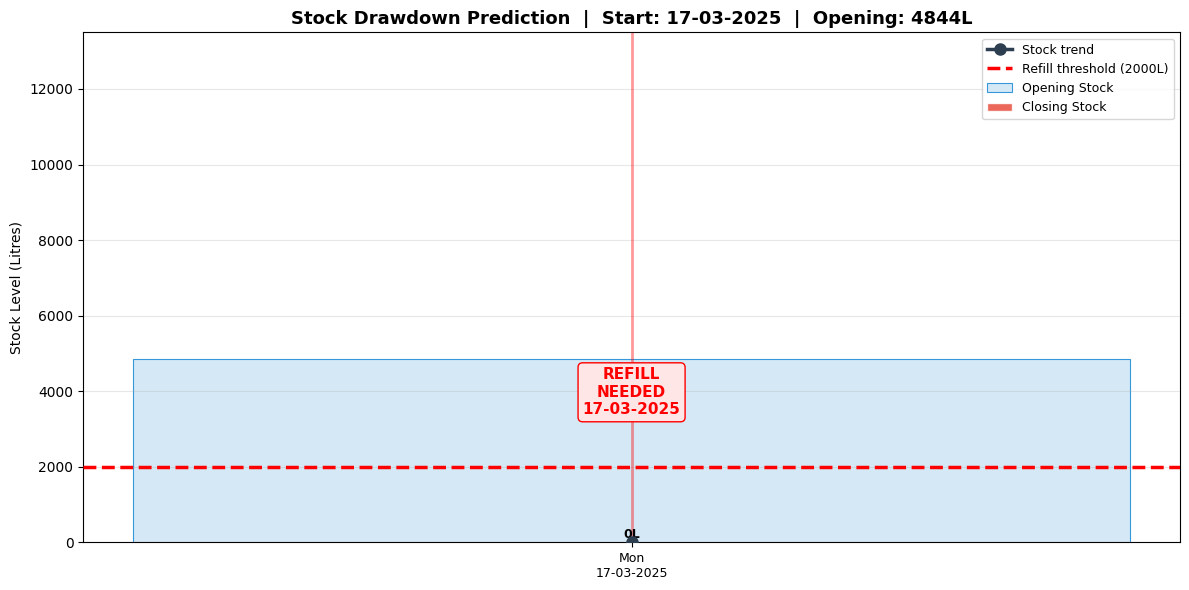

Saved: data/viz_next_refill_prediction.png


In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

dates        = sim_df['Date'].tolist()
stock_levels = sim_df['Closing_Stock'].tolist()
open_levels  = sim_df['Opening_Stock'].tolist()

# Plot opening stock bars
bar_colors = ['#e74c3c' if s < REFILL_THRESHOLD else '#3498db' for s in stock_levels]
ax.bar(range(len(dates)), open_levels,
       color='#d5e8f5', edgecolor='#3498db', linewidth=0.8, label='Opening Stock')
ax.bar(range(len(dates)), stock_levels,
       color=bar_colors, alpha=0.85, edgecolor='white', label='Closing Stock')

# Closing stock line
ax.plot(range(len(dates)), stock_levels,
        color='#2c3e50', marker='o', linewidth=2.5,
        markersize=8, zorder=5, label='Stock trend')

# Label each point
for i, (s, o) in enumerate(zip(stock_levels, open_levels)):
    ax.text(i, s + 120, f'{s:.0f}L', ha='center', fontsize=9, fontweight='bold')

# Refill threshold line
ax.axhline(REFILL_THRESHOLD, color='red', linestyle='--',
           linewidth=2.5, label=f'Refill threshold ({REFILL_THRESHOLD}L)', zorder=6)

# Highlight refill day
if refill_day:
    refill_idx = len(sim_df) - 1
    ax.axvline(refill_idx, color='red', linestyle='-', linewidth=2, alpha=0.4)
    ax.text(refill_idx, current_stock * 0.7,
            f'REFILL\nNEEDED\n{refill_day["date"]}',
            ha='center', color='red', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe6e6', edgecolor='red'))

ax.set_xticks(range(len(dates)))
ax.set_xticklabels(
    [f'{row["Day"][:3]}\n{row["Date"]}' for _, row in sim_df.iterrows()],
    fontsize=9
)
ax.set_title(
    f'Stock Drawdown Prediction  |  Start: {start_date.strftime("%d-%m-%Y")}  |  Opening: {current_stock}L',
    fontweight='bold', fontsize=13
)
ax.set_ylabel('Stock Level (Litres)')
ax.set_ylim(0, TANK_CAPACITY + 1500)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/viz_next_refill_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/viz_next_refill_prediction.png')

## Step 4 — Final Answer

In [24]:
print('=' * 55)
print('  NEXT REFILL PREDICTION')
print(f'  Current stock : {current_stock} L')
print(f'  From date     : {start_date.strftime("%d-%m-%Y")}')
print('=' * 55)

if refill_day:
    print(f'\n  Next refill needed on:')
    print(f'  Date          : {refill_day["date"]}  ({refill_day["day"]})')
    print(f'  Days from now : {refill_day["days_from_now"]} day(s)')
    print(f'  Opening stock : {refill_day["opening"]} L')
    print(f'  Expected sold : {refill_day["sold"]} L')
    print(f'  Closing stock : {refill_day["closing"]} L  (below {REFILL_THRESHOLD}L threshold)')
    print(f'  ML confidence : {refill_day["ml_prob"]:.0%}')
else:
    print(f'\n  No refill needed in the next 30 days.')
    print(f'  Current stock of {current_stock}L is sufficient.')

print('=' * 55)

  NEXT REFILL PREDICTION
  Current stock : 4844 L
  From date     : 17-03-2025

  Next refill needed on:
  Date          : 17-03-2025  (Monday)
  Days from now : 1 day(s)
  Opening stock : 4844 L
  Expected sold : 4844 L
  Closing stock : 0 L  (below 2000L threshold)
  ML confidence : 100%
